Mount Google Drive and extract the CelebA dataset.



In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
!rm -rf /content/data

In [19]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Week5 SOC/archive (10).zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")

Extraction complete!


Create a custom PyTorch Dataset class to load CelebA images along with their attribute labels.

In [20]:
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset

class CelebAKaggle(Dataset):

    def __init__(self, root, transform=None):

        self.root = root
        self.transform = transform

        self.attr = pd.read_csv(
            os.path.join(root, "list_attr_celeba.csv")
        )

        self.image_dir = os.path.join(root, "img_align_celeba", "img_align_celeba")

        self.image_names = self.attr.iloc[:,0].values
        self.attributes = self.attr.iloc[:,1:].values.astype("float32")

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):

        img_path = os.path.join(
            self.image_dir,
            self.image_names[idx]
        )

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        attrs = torch.tensor(self.attributes[idx])

        return image, attrs

Load the pretrained VAE model and prepare the dataset for latent space experiments.

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import imageio  # for GIF creation
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== LOAD YOUR MODEL =====
# Option A: from Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# MODEL_PATH = "/content/drive/MyDrive/soc_diffusion/week5/face_vae_final.pt"

# Option B: upload directly
# from google.colab import files
# uploaded = files.upload()
# MODEL_PATH = list(uploaded.keys())[0]

MODEL_PATH = "/content/drive/MyDrive/Week5 SOC/model.pt" # [PLAY] change to your file path

# Recreate the model architecture (must match Week 5 exactly)
class FaceVAE(nn.Module):
    def __init__(self, latent_dim=128, hidden_dims=None, kernel_size=3):
        super().__init__()
        self.latent_dim = latent_dim
        if hidden_dims is None:
            hidden_dims = [64, 128, 256, 512]  # must match training config!

        # Encoder
        encoder_layers = []
        in_ch = 3
        for out_ch in hidden_dims:
            encoder_layers.extend([
                nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, stride=2, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(),
            ])
            in_ch = out_ch
        encoder_layers.append(nn.Flatten())
        self.encoder = nn.Sequential(*encoder_layers)

        n_layers = len(hidden_dims)
        spatial_size = 64 // (2 ** n_layers)
        self.flattened_size = hidden_dims[-1] * (spatial_size ** 2)
        self.spatial_size = spatial_size
        self.last_channel = hidden_dims[-1]

        self.fc_mu    = nn.Linear(self.flattened_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flattened_size, latent_dim)

        # Decoder
        self.decoder_input = nn.Linear(latent_dim, self.flattened_size)
        decoder_layers = []
        rev_dims = list(reversed(hidden_dims))
        for i in range(len(rev_dims) - 1):
            decoder_layers.extend([
                nn.ConvTranspose2d(rev_dims[i], rev_dims[i+1],
                                   kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(rev_dims[i+1]),
                nn.ReLU(),
            ])
        decoder_layers.extend([
            nn.ConvTranspose2d(rev_dims[-1], 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        ])
        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.view(-1, self.last_channel, self.spatial_size, self.spatial_size)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

model = FaceVAE(latent_dim=128).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print("Model loaded successfully!")

# Load CelebA for exploration
image_size = 64
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
])

# Load with attributes for Part 3 (attribute discovery)
dataset_with_attrs = CelebAKaggle(
    "/content/data",
    transform=transform
)

dataset = dataset_with_attrs

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)


# Also a plain version for encoder-only use




Model loaded successfully!


Generate a smooth interpolation between two faces by interpolating in the latent space.

GIF saved as face_morph.gif


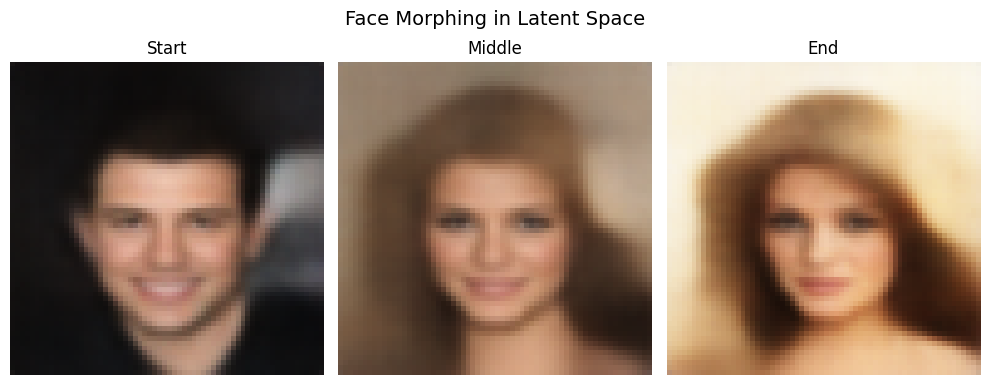

In [22]:
@torch.no_grad()
def face_morph(model, img1, img2, steps=30):  # [PLAY] more steps = smoother GIF
    """
    img1, img2: [1, 3, 64, 64] tensors
    Returns: list of [3, 64, 64] numpy arrays (the morph frames)
    """
    # Encode both faces
    mu1, _ = model.encode(img1.to(device))
    mu2, _ = model.encode(img2.to(device))

    frames = []
    for alpha in np.linspace(0, 1, steps):
        # Spherical interpolation (slerp) gives smoother morphs than linear
        # But linear works fine for small steps. Use linear for simplicity:
        z_interp = (1 - alpha) * mu1 + alpha * mu2
        recon = model.decode(z_interp)
        frame = recon[0].cpu().permute(1, 2, 0).numpy()
        frame = np.clip(frame, 0, 1)
        frames.append((frame * 255).astype(np.uint8))

    return frames


# Get two random faces
x, _ = next(iter(loader))
img1 = x[0:1]
img2 = x[1:2]

# Generate morph
frames = face_morph(model, img1, img2, steps=30)

# Save as GIF
imageio.mimsave('face_morph.gif', frames, duration=0.1, loop=0)
print("GIF saved as face_morph.gif")

# Show start, middle, end
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].imshow(frames[0])
axes[0].set_title("Start", fontsize=12)
axes[0].axis('off')
axes[1].imshow(frames[15])
axes[1].set_title("Middle", fontsize=12)
axes[1].axis('off')
axes[2].imshow(frames[-1])
axes[2].set_title("End", fontsize=12)
axes[2].axis('off')
plt.suptitle("Face Morphing in Latent Space", fontsize=14)
plt.tight_layout()
plt.show()

Compute latent attribute directions using CelebA labels and visualize how changing the "Smiling" attribute affects a face.

Computing 'Smiling' vector...


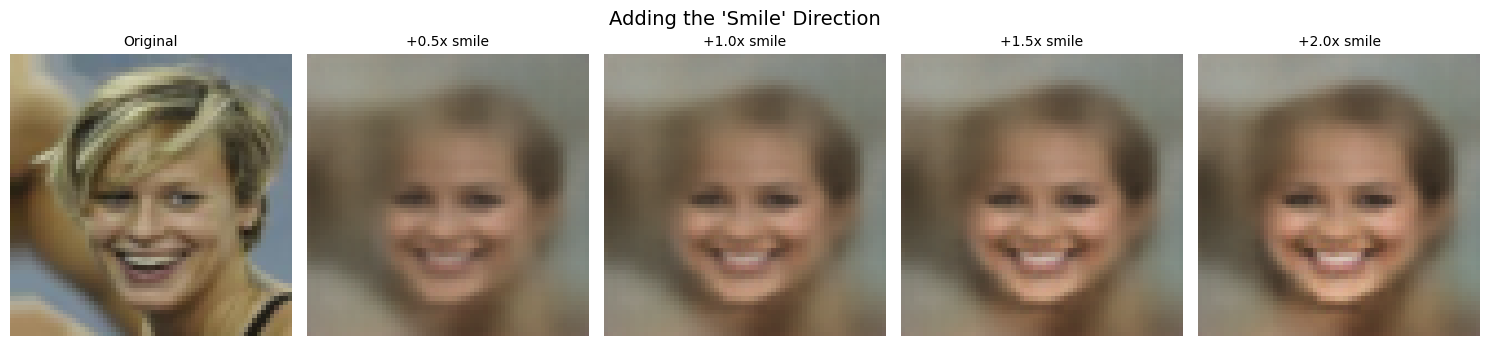

In [23]:
@torch.no_grad()
def encode_batch(model, loader, max_batch=1000):
    """Encode a batch of images to get their mu vectors."""
    all_mu = []
    all_attrs = None
    for x, attrs in loader:
        mu, _ = model.encode(x.to(device))
        all_mu.append(mu.cpu())
        if all_attrs is None:
            all_attrs = attrs
        else:
            all_attrs = torch.cat([all_attrs, attrs])
        if len(torch.cat(all_mu)) >= max_batch:
            break
    return torch.cat(all_mu), all_attrs


# CelebA attributes: each row is a 40-dim binary vector
# Index mapping (see https://github.com/taki0112/CelebA/blob/master/list_attr_celeba.txt)
ATTR_NAMES = [
    '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes',
    'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair',
    'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin',
    'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones',
    'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard',
    'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline',
    'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair',
    'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick',
    'Wearing_Necklace', 'Wearing_Necktie', 'Young'
]

def get_attribute_vector(model, loader_with_attrs, attr_name, n_samples=2000):  # [PLAY] more samples = cleaner vector
    """
    Find the latent direction for an attribute.
    Returns: vector of shape [latent_dim]
    """
    attr_idx = ATTR_NAMES.index(attr_name)

    # Encode faces
    mu_vectors, attr_labels = encode_batch(model, loader_with_attrs, max_batch=n_samples)

    # Split into with and without the attribute
    has_attr = attr_labels[:, attr_idx] == 1
    no_attr  = attr_labels[:, attr_idx] == -1  # CelebA uses -1 for False

    mu_with = mu_vectors[has_attr]
    mu_without = mu_vectors[no_attr]

    if len(mu_with) < 10 or len(mu_without) < 10:
        print(f"Warning: not enough samples for '{attr_name}'. Got {len(mu_with)}/{len(mu_without)}")
        return None

    # Attribute vector = average(with_attr) - average(without_attr)
    attr_vector = mu_with.mean(dim=0) - mu_without.mean(dim=0)
    return attr_vector


@torch.no_grad()
def apply_attribute(model, img, attr_vector, strength=1.0):  # [PLAY] try 0.5, 2.0, 3.0
    """Add an attribute vector to a face's latent code."""
    mu, _ = model.encode(img.to(device))
    mu_modified = mu + strength * attr_vector.to(device)
    recon = model.decode(mu_modified)
    return recon.cpu()


# Load attribute-labeled data
attr_loader = DataLoader(dataset_with_attrs, batch_size=128, shuffle=True)

# Find the "Smiling" direction
print("Computing 'Smiling' vector...")
smile_vector = get_attribute_vector(model, attr_loader, 'Smiling', n_samples=2000)

if smile_vector is not None:
    # Apply to a neutral face
    x, _ = next(iter(loader))
    test_face = x[0:1]

    fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
    axes[0].imshow(test_face[0].permute(1, 2, 0))
    axes[0].set_title("Original", fontsize=10)
    axes[0].axis('off')

    for i, strength in enumerate([0.5, 1.0, 1.5, 2.0]):
        modified = apply_attribute(model, test_face, smile_vector, strength=strength)
        axes[i+1].imshow(modified[0].permute(1, 2, 0))
        axes[i+1].set_title(f"+{strength}x smile", fontsize=10)
        axes[i+1].axis('off')

    plt.suptitle("Adding the 'Smile' Direction", fontsize=14)
    plt.tight_layout()
    plt.show()

Combine multiple latent attribute directions to manipulate more than one facial attribute simultaneously.

Computing attribute vectors...


 20%|██        | 1/5 [00:10<00:43, 10.90s/it]

  Smiling: vector norm = 1.564


 40%|████      | 2/5 [00:21<00:33, 11.01s/it]

  Male: vector norm = 1.581


...

  Eyeglasses: vector norm = 1.887


 80%|████████  | 4/5 [00:42<00:10, 10.48s/it]

  Young: vector norm = 1.259


100%|██████████| 5/5 [00:52<00:00, 10.52s/it]

  Pale_Skin: vector norm = 1.994

Found 5/5 attribute directions


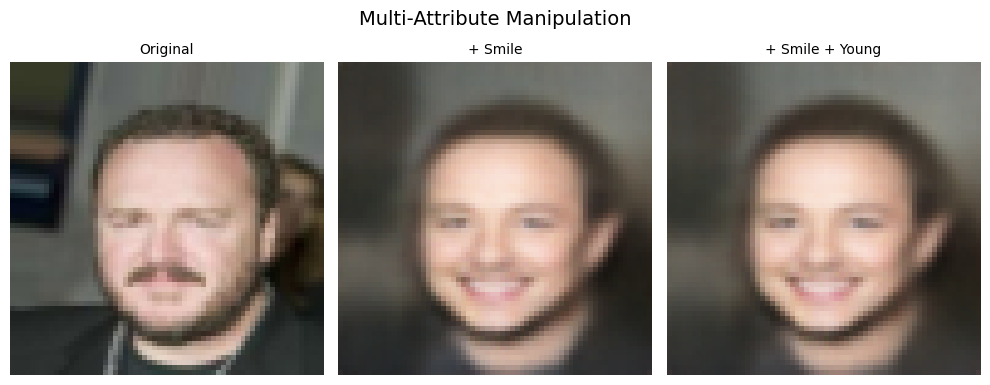

In [24]:
# Find multiple attribute directions
attributes_to_find = ['Smiling', 'Male', 'Eyeglasses', 'Young', 'Pale_Skin']
attr_vectors = {}

print("Computing attribute vectors...")
for attr in tqdm(attributes_to_find):
    vec = get_attribute_vector(model, attr_loader, attr, n_samples=2000)
    if vec is not None:
        attr_vectors[attr] = vec
        print(f"  {attr}: vector norm = {vec.norm():.3f}")

print(f"\nFound {len(attr_vectors)}/{len(attributes_to_find)} attribute directions")

# Cross-attribute arithmetic: make a non-smiling man smile
if 'Smiling' in attr_vectors and 'Male' in attr_vectors:
    test_face = x[5:6]  # another random face

    mu, _ = model.encode(test_face.to(device))

    # Apply smiling
    mu_smiling = mu + attr_vectors['Smiling'].to(device)

    fig, axes = plt.subplots(1, 3, figsize=(10, 4))
    axes[0].imshow(test_face[0].permute(1, 2, 0))
    axes[0].set_title("Original", fontsize=10)
    axes[0].axis('off')

    recon_smile = model.decode(mu_smiling)
    axes[1].imshow(recon_smile[0].detach().cpu().permute(1, 2, 0))
    axes[1].set_title("+ Smile", fontsize=10)
    axes[1].axis('off')

    # Apply multiple attributes
    mu_combo = mu + attr_vectors['Smiling'].to(device) + attr_vectors['Young'].to(device) * 0.5
    recon_combo = model.decode(mu_combo)
    axes[2].imshow(recon_combo[0].detach().cpu().permute(1, 2, 0))
    axes[2].set_title("+ Smile + Young", fontsize=10)
    axes[2].axis('off')

    plt.suptitle("Multi-Attribute Manipulation", fontsize=14)
    plt.tight_layout()
    plt.show()

Visualize the effect of different strengths for multiple attribute directions.

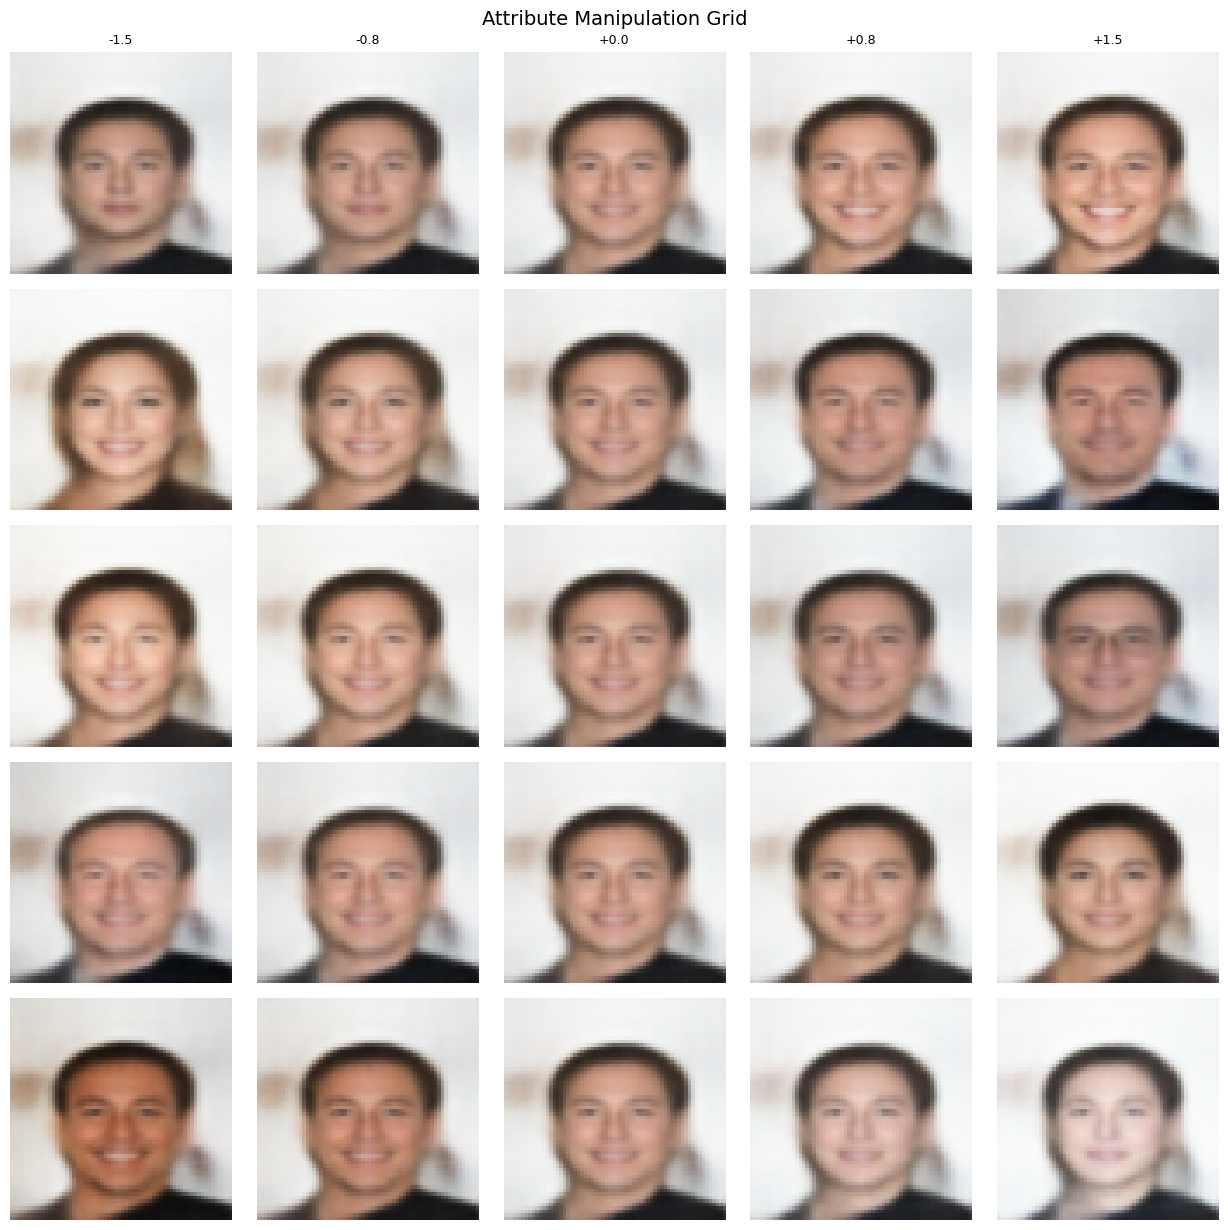

In [25]:
@torch.no_grad()
def attribute_grid(model, loader, attr_vectors, face_idx=0, strengths=[-1.5, -0.75, 0, 0.75, 1.5] ): # [PLAY] try different strength ranges):
    """Create a grid showing one face modified by multiple attributes at multiple strengths."""
    x, _ = next(iter(loader))
    base_face = x[face_idx:face_idx+1]

    n_attrs = len(attr_vectors)
    n_strengths = len(strengths)

    fig, axes = plt.subplots(n_attrs, n_strengths,
                             figsize=(n_strengths * 2.5, n_attrs * 2.5))

    for row, (attr_name, vec) in enumerate(attr_vectors.items()):
        for col, strength in enumerate(strengths):
            modified = apply_attribute(model, base_face, vec, strength=strength)
            axes[row, col].imshow(modified[0].permute(1, 2, 0))
            axes[row, col].axis('off')

            if col == 0:
                axes[row, col].set_ylabel(attr_name, fontsize=10, rotation=0,
                                         labelpad=50, va='center')
            if row == 0:
                axes[row, col].set_title(f"{strength:+.1f}", fontsize=9)

    plt.suptitle("Attribute Manipulation Grid", fontsize=14)
    plt.tight_layout()
    plt.show()

if len(attr_vectors) >= 3:
    attribute_grid(model, loader, attr_vectors)

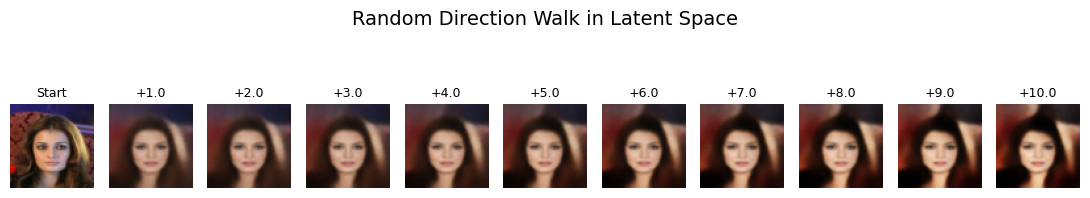

In [26]:
@torch.no_grad()
def random_walk(model, base_face, n_steps=10, step_size=0.5):  # [PLAY] try n_steps=20, step_size=2.0
    """Walk in a random direction from a face's latent code."""
    mu, _ = model.encode(base_face.to(device))

    # Pick a random unit direction
    random_direction = torch.randn(1, model.latent_dim).to(device)
    random_direction = random_direction / random_direction.norm()

    fig, axes = plt.subplots(1, n_steps + 1, figsize=(n_steps + 1, 2.5))
    axes[0].imshow(base_face[0].permute(1, 2, 0))
    axes[0].set_title("Start", fontsize=9)
    axes[0].axis('off')

    for i in range(1, n_steps + 1):
        z = mu + step_size * i * random_direction
        recon = model.decode(z)
        axes[i].imshow(recon[0].cpu().permute(1, 2, 0))
        axes[i].set_title(f"+{i*step_size:.1f}", fontsize=9)
        axes[i].axis('off')

    plt.suptitle("Random Direction Walk in Latent Space", fontsize=14)
    plt.tight_layout()
    plt.show()

x, _ = next(iter(loader))
random_walk(model, x[3:4], n_steps=10, step_size=1.0)  # [PLAY] explore different directions

# Reflection

### 1. Which attribute does your model represent best? Which is worst? Why do you think that is?

Out of all the attributes, **Smiling** worked the best. As I increased the smile strength, the expression changed gradually while the face still looked like the same person. The **Pale Skin** attribute was the least convincing because it mostly changed the brightness of the image instead of clearly changing the skin tone. I think this happens because facial expressions are easier for the model to learn than subtle features like skin tone, which can also be affected by lighting.

### 2. If you were building a face-editing app, what would you need to improve about your VAE?

If I were building a face-editing app, I would first improve the image quality because the reconstructed faces are still a bit blurry. I would also try to make the latent space more organized so that changing one feature doesn't affect other parts of the face. Training on higher-resolution images or using a better generative model could make the edits look much more realistic.
